In [10]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt 
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import chi2
import pingouin as pg
import ipywidgets as widgets
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

# Schließende Statistik

### Ziele der Übung

- Punktschätzer
- Konfidenzintervalle
- Hypothesentests

**Hinweise:**

- Normalverteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm
- t-Verteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
- $\chi^2$-Verteilung: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html?highlight=chi2

## Aufgabe 1: Konfidenzintervall

Im Datensatz "BeerAll" ist der Inhalt der Grundgesamtheit aller abgefüllten Bierflaschen dargestellt. Da es in der Praxis zu aufwändig wäre, jede einzelne Flasche zu überprüfen, wird typischerweise ein Stichprobensample gezogen. Anschließend wird ein Konfidenzintervall für den Erwartungswert des Inhalts berechnet. Auf Basis dieses Intervalls lässt sich beurteilen, ob die Sollmenge noch eingehalten wird oder ob der Abfüllprozess neu kalibriert werden muss.

Nutze die untenstehende interaktive Oberfläche (GUI), um den Einfluss verschiedener Parameter auf die Länge des Konfidenzintervalls zu erkunden. Beantworte dabei folgende Fragen:

- **Anzahl der Stichproben**: Wie verändert sich die Darstellung, wenn du die Anzahl der Stichproben erhöhst oder verringerst?
(Hinweis: Beobachte dabei nicht die Länge einzelner Intervalle, sondern wie sich das Gesamtbild der Intervalle verändert.)

- **Größe der Stichprobe (n)**: Wie wirkt sich eine größere Stichprobe auf die Länge eines einzelnen Konfidenzintervalls aus?

- **Signifikanzniveau $\alpha$ (bzw. Konfidenzniveau $1 - \alpha$)**: Was passiert mit der Länge des Konfidenzintervalls, wenn $\alpha$ vergrößert oder verkleinert wird?

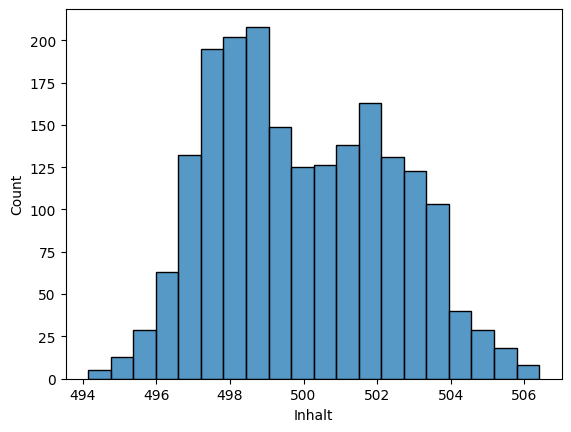

In [11]:
beer = pd.read_csv('BeerAll.csv', index_col = 0)
sn.histplot(data = beer, x = 'Inhalt')
plt.show()

In [12]:
# Funktion zum Plotten der Konfidenzintervalle
def plot_confidence_intervals(data, colname, num_samples, n, alpha):
    means = []
    lower_bounds = []
    upper_bounds = []
    true_mean = data[colname].mean()
    
    for i in range(num_samples):
        sample_i = data.sample(n)
        mean_i = sample_i[colname].mean()
        s_i = sample_i[colname].std(ddof=1)
        t_stats = t.ppf(1 - alpha / 2, n - 1)

        # Berechnung des Konfidenzintervalls
        lower_bounds.append(mean_i - t_stats * s_i / np.sqrt(n))
        upper_bounds.append(mean_i + t_stats * s_i / np.sqrt(n))
        means.append(mean_i)
    
    # Coverage berechnen
    covers_EW = [(low <= true_mean <= up) for low, up in zip(lower_bounds, upper_bounds)]
    coverage = np.mean(covers_EW) * 100  # in Prozent
    num_included = sum(covers_EW)

    # Ausgabe der Kennzahlen
    print(f"Anzahl der Stichproben: {num_samples}")
    print(f"alpha: {alpha}")
    print(f"Konfidenzintervall zum Niveau (1 - alpha): {1-alpha}")
    print(f"Größe der Stichprobe jeweils: {n} Beobachtungen")
    print(f"Abdeckungsrate (Coverage): {coverage:.2f}% ({num_included} von {num_samples} Intervallen) ")
    
    # Plot der Konfidenzintervalle
    fig, ax = plt.subplots(figsize=(10, min(0.25 * num_samples, 10)))
    for i in range(num_samples):
        color = 'green' if covers_EW[i] else 'red'
        ax.plot([lower_bounds[i], upper_bounds[i]], [i, i], color=color)
        ax.plot(means[i], i, 'o', color='black')
    
    ax.axvline(data[colname].mean(), color='blue', linestyle='--', label='Wahrer Mittelwert')
    ax.set_xlabel("Wert")
    ax.set_ylabel("Stichprobe")
    ax.set_title(f"Konfidenzintervalle für {num_samples} Stichproben")
    ax.set_xlim(data[colname].min(), data[colname].max())
    ax.legend()
    plt.show()

In [16]:
# Funktion um das GUI aufzubauen
def explore_confidence_intervals():
    slider_stichproben = widgets.IntSlider(
        value=10,
        min=1,
        max=100,
        step=1,
        description='Anzahl Stichproben:',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    # Slicer für Größe der Stichprobe
    slider_stichprobengroesse = widgets.IntSlider(
        value = 30,
        min = 1,
        max= 1000,
        step=1,
        description='Größe der Stichprobe:',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    # Slicer für Konfidenzniveau (alpha)
    slider_alpha = widgets.FloatSlider(
        value=0.05,
        min=0.01,
        max=0.5,
        step=0.01,
        description='alpha:',
        continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )
    
    # Funktion für den Button, um das Plot zu erzeugen
    def on_button_click(b):
        # Aufruf der Funktion zum Plotten mit den gewählten Werten
        plot_confidence_intervals(beer, colname='Inhalt', num_samples=slider_stichproben.value, n=slider_stichprobengroesse.value, alpha=slider_alpha.value)

    # Button für das Plotten
    button = widgets.Button(description="Visualisiere die Konfidenzintervalle", 
                            layout=widgets.Layout(width='500px'),     
                            style={'button_color': 'lightblue'}   # Hintergrundfarbe des Buttons
                           )
    button.on_click(on_button_click)
    
    # Anzeige der Widgets
    display(slider_stichproben, slider_stichprobengroesse, slider_alpha, button)

IntSlider(value=10, continuous_update=False, description='Anzahl Stichproben:', layout=Layout(width='400px'), …

IntSlider(value=30, continuous_update=False, description='Größe der Stichprobe:', layout=Layout(width='400px')…

FloatSlider(value=0.05, continuous_update=False, description='alpha:', layout=Layout(width='400px'), max=0.5, …

Button(description='Visualisiere die Konfidenzintervalle', layout=Layout(width='500px'), style=ButtonStyle(but…

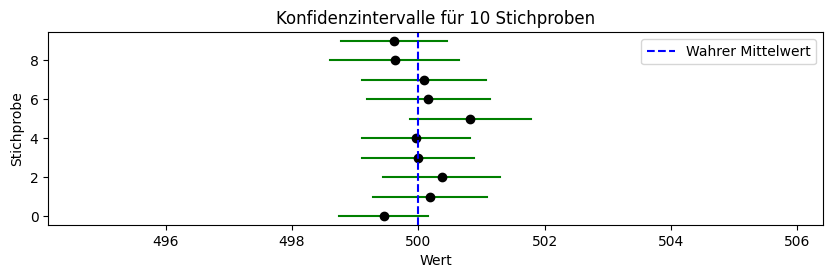

In [15]:
explore_confidence_intervals()

## Aufgabe 2: Pharmaindustrie

Die Produktion von einem schmerzstillenden Medikament wurde untersucht. Der Anteil von Paracetamol in $mg$ wurde wie folgt gemessen: $4.90, 5.13, 4.95, 4.84, 5.00, 5.00, 4.93, 5.00, 4.93, 4.77$. Zusätzlich weiß man aus Erfahrung, dass der Anteil von Paracetamol in dem bestimmten Medikament normalverteilt ist und mit $\sigma = 0.1\ mg$ um den eingestellten Wert streut. 
- Bestimme das zweiseitige Konfidenzintervall für den Erwartungswert $\mu$ zum Niveau $95\%$. Was bedeutet das?
- Angenommen wir hätten $\sigma$ erst schätzen müssen, wie schaut nun das Konfidenzintervall aus?
- Angenommen $\sigma$ ist unbekannt und wir wollen ein Konfidenzintervall für $\sigma$ bestimmen? 

In [ ]:
# Daten
daten = np.array([4.90, 5.13, 4.95, 4.84, 5.00, 5.00, 4.93, 5.00, 4.93, 4.77])
n = len(daten)
x_bar = np.mean(daten)
alpha = 0.05

print(f"Stichprobe: {daten}")
print(f"n = {n}, x̄ = {x_bar:.4f} mg, α = {alpha}\n")

# ========================================
# Teil 1: σ bekannt (σ = 0.1 mg)
# ========================================
print("TEIL 1: KI für μ mit BEKANNTEM σ = 0.1 mg")
print("-" * 50)

sigma = 0.1
z = norm.ppf(1 - alpha/2)
margin = z * sigma / np.sqrt(n)

lower = x_bar - margin
upper = x_bar + margin

print(f"95%-KI: [{lower:.4f}, {upper:.4f}] mg")
print(f"→ Verwendet: Normalverteilung (z = {z:.3f})\n")

# ========================================
# Teil 2: σ unbekannt (geschätzt)
# ========================================
print("TEIL 2: KI für μ mit UNBEKANNTEM σ")
print("-" * 50)

s = np.std(daten, ddof=1)
t_wert = t.ppf(1 - alpha/2, df=n-1)
margin = t_wert * s / np.sqrt(n)

lower = x_bar - margin
upper = x_bar + margin

print(f"s = {s:.4f} mg")
print(f"95%-KI: [{lower:.4f}, {upper:.4f}] mg")
print(f"→ Verwendet: t-Verteilung (t = {t_wert:.3f}, df = {n-1})\n")

# ========================================
# Teil 3: KI für σ
# ========================================
print("TEIL 3: KI für σ")
print("-" * 50)

chi2_lower = chi2.ppf(alpha/2, df=n-1)
chi2_upper = chi2.ppf(1 - alpha/2, df=n-1)

sigma_lower = np.sqrt((n-1) * s**2 / chi2_upper)
sigma_upper = np.sqrt((n-1) * s**2 / chi2_lower)

print(f"95%-KI: [{sigma_lower:.4f}, {sigma_upper:.4f}] mg")
print(f"→ Verwendet: χ²-Verteilung (df = {n-1})")

## Aufgabe 3: Pharmaindustrie

Die Produktion von einem schmerzstillenden Medikament wurde untersucht. Der Anteil von Paracetamol in $mg$ wurde wie folgt gemessen: $4.90, 5.13, 4.95, 4.84, 5.00, 5.00, 4.93, 5.00, 4.93, 4.77$. Zusätzlich weiß man aus Erfahrung, dass der Anteil von Paracetamol in dem bestimmten Medikament normalverteilt ist und mit $\sigma = 0.1\ mg$ um den eingestellten Wert streut. 
- Muss der Produktionsprozess neu kalibriert werden oder gilt weiterhin $\mu~=~5\ mg$ ($\alpha = 0.05$)?